In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df=pd.read_csv("/kaggle/input/datasets/stealthtechnologies/predict-autism-spectrum-disorder-asd/Autism.csv")

In [3]:
df.shape

(704, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethnicity        704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  contry_of_res    704 non-null    object
 16  used_app_before  704 non-null    object
 17  result           704 non-null    in

In [5]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [6]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [7]:
print(df["gender"].unique())

['f' 'm']


In [8]:
female=0
male=0
for col in df["gender"]:
    if col=="f":
        female+=1
    else:
        male+=1
print(f"Male: {male}")
print(f"Female: {female}")

Male: 367
Female: 337


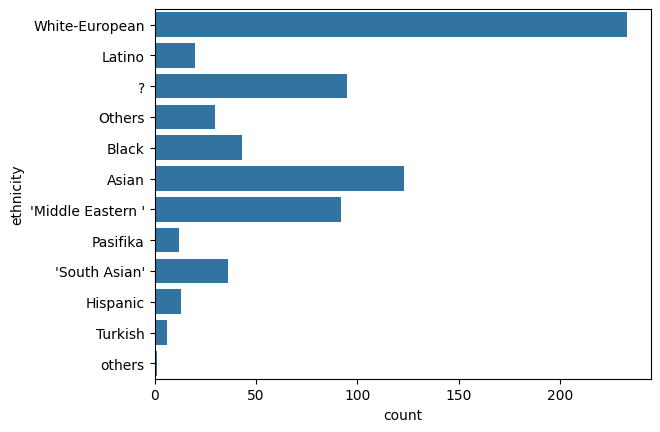

In [9]:
sns.countplot(df["ethnicity"])
plt.show()

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
data_X=df.copy()

In [12]:
data_X=data_X.drop("Class/ASD",axis=1)
data_X=data_X.drop("age_desc",axis=1)
data_X


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,relation
0,1,1,1,1,0,0,1,1,0,0,26,f,White-European,no,no,'United States',no,6,Self
1,1,1,0,1,0,0,0,1,0,1,24,m,Latino,no,yes,Brazil,no,5,Self
2,1,1,0,1,1,0,1,1,1,1,27,m,Latino,yes,yes,Spain,no,8,Parent
3,1,1,0,1,0,0,1,1,0,1,35,f,White-European,no,yes,'United States',no,6,Self
4,1,0,0,0,0,0,0,1,0,0,40,f,?,no,no,Egypt,no,2,?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,25,f,White-European,no,no,Russia,no,7,Self
700,1,0,0,0,0,0,0,1,0,1,34,m,Hispanic,no,no,Mexico,no,3,Parent
701,1,0,1,1,1,0,1,1,0,1,24,f,?,no,no,Russia,no,7,?
702,1,0,0,1,1,0,1,0,1,1,35,m,'South Asian',no,no,Pakistan,no,6,Self


In [13]:
y=df["Class/ASD"]
y_df=pd.DataFrame(y,columns=["Class/ASD"])
print(y_df.value_counts())
print(y_df.value_counts(normalize=True)*100)

Class/ASD
NO           515
YES          189
Name: count, dtype: int64
Class/ASD
NO           73.153409
YES          26.846591
Name: proportion, dtype: float64


In [14]:
print(data_X.shape)
print(y_df.shape)

(704, 19)
(704, 1)


In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [16]:
categoricalCols=data_X.select_dtypes(include="object")
categoricalCols

,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,relation
0,26,f,White-European,no,no,'United States',no,Self
1,24,m,Latino,no,yes,Brazil,no,Self
2,27,m,Latino,yes,yes,Spain,no,Parent
3,35,f,White-European,no,yes,'United States',no,Self
4,40,f,?,no,no,Egypt,no,?
...,...,...,...,...,...,...,...,...
699,25,f,White-European,no,no,Russia,no,Self
700,34,m,Hispanic,no,no,Mexico,no,Parent
701,24,f,?,no,no,Russia,no,?
702,35,m,'South Asian',no,no,Pakistan,no,Self


In [17]:
label_encoder=LabelEncoder()
for col in ["ethnicity","contry_of_res","relation","age"]:
    data_X[col]=label_encoder.fit_transform(data_X[col])

In [18]:
data_X

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,relation
0,1,1,1,1,0,0,1,1,0,0,9,f,10,no,no,10,no,6,5
1,1,1,0,1,0,0,0,1,0,1,7,m,6,no,yes,25,no,5,5
2,1,1,0,1,1,0,1,1,1,1,10,m,6,yes,yes,61,no,8,3
3,1,1,0,1,0,0,1,1,0,1,18,f,10,no,yes,10,no,6,5
4,1,0,0,0,0,0,0,1,0,0,24,f,2,no,no,32,no,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,8,f,10,no,no,59,no,7,5
700,1,0,0,0,0,0,0,1,0,1,17,m,5,no,no,49,no,3,3
701,1,0,1,1,1,0,1,1,0,1,7,f,2,no,no,59,no,7,1
702,1,0,0,1,1,0,1,0,1,1,18,m,1,no,no,55,no,6,5


In [19]:
oneHotEncoder = OneHotEncoder(sparse_output=False)
for col in ["gender","jundice","austim","used_app_before"]:
    oneHotEncoded = oneHotEncoder.fit_transform(data_X[[col]])
    column_names = oneHotEncoder.get_feature_names_out([col])
    df1 = pd.DataFrame(oneHotEncoded, columns=column_names)
    data_X = pd.concat([data_X,df1],axis=1)
    data_X = data_X.drop(columns=[col], inplace=False)

In [20]:
data_X

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,result,relation,gender_f,gender_m,jundice_no,jundice_yes,austim_no,austim_yes,used_app_before_no,used_app_before_yes
0,1,1,1,1,0,0,1,1,0,0,...,6,5,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1,1,0,1,0,0,0,1,0,1,...,5,5,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
2,1,1,0,1,1,0,1,1,1,1,...,8,3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,1,1,0,1,0,0,1,1,0,1,...,6,5,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,1,0,0,0,0,0,0,1,0,0,...,2,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,7,5,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
700,1,0,0,0,0,0,0,1,0,1,...,3,3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
701,1,0,1,1,1,0,1,1,0,1,...,7,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
702,1,0,0,1,1,0,1,0,1,1,...,6,5,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


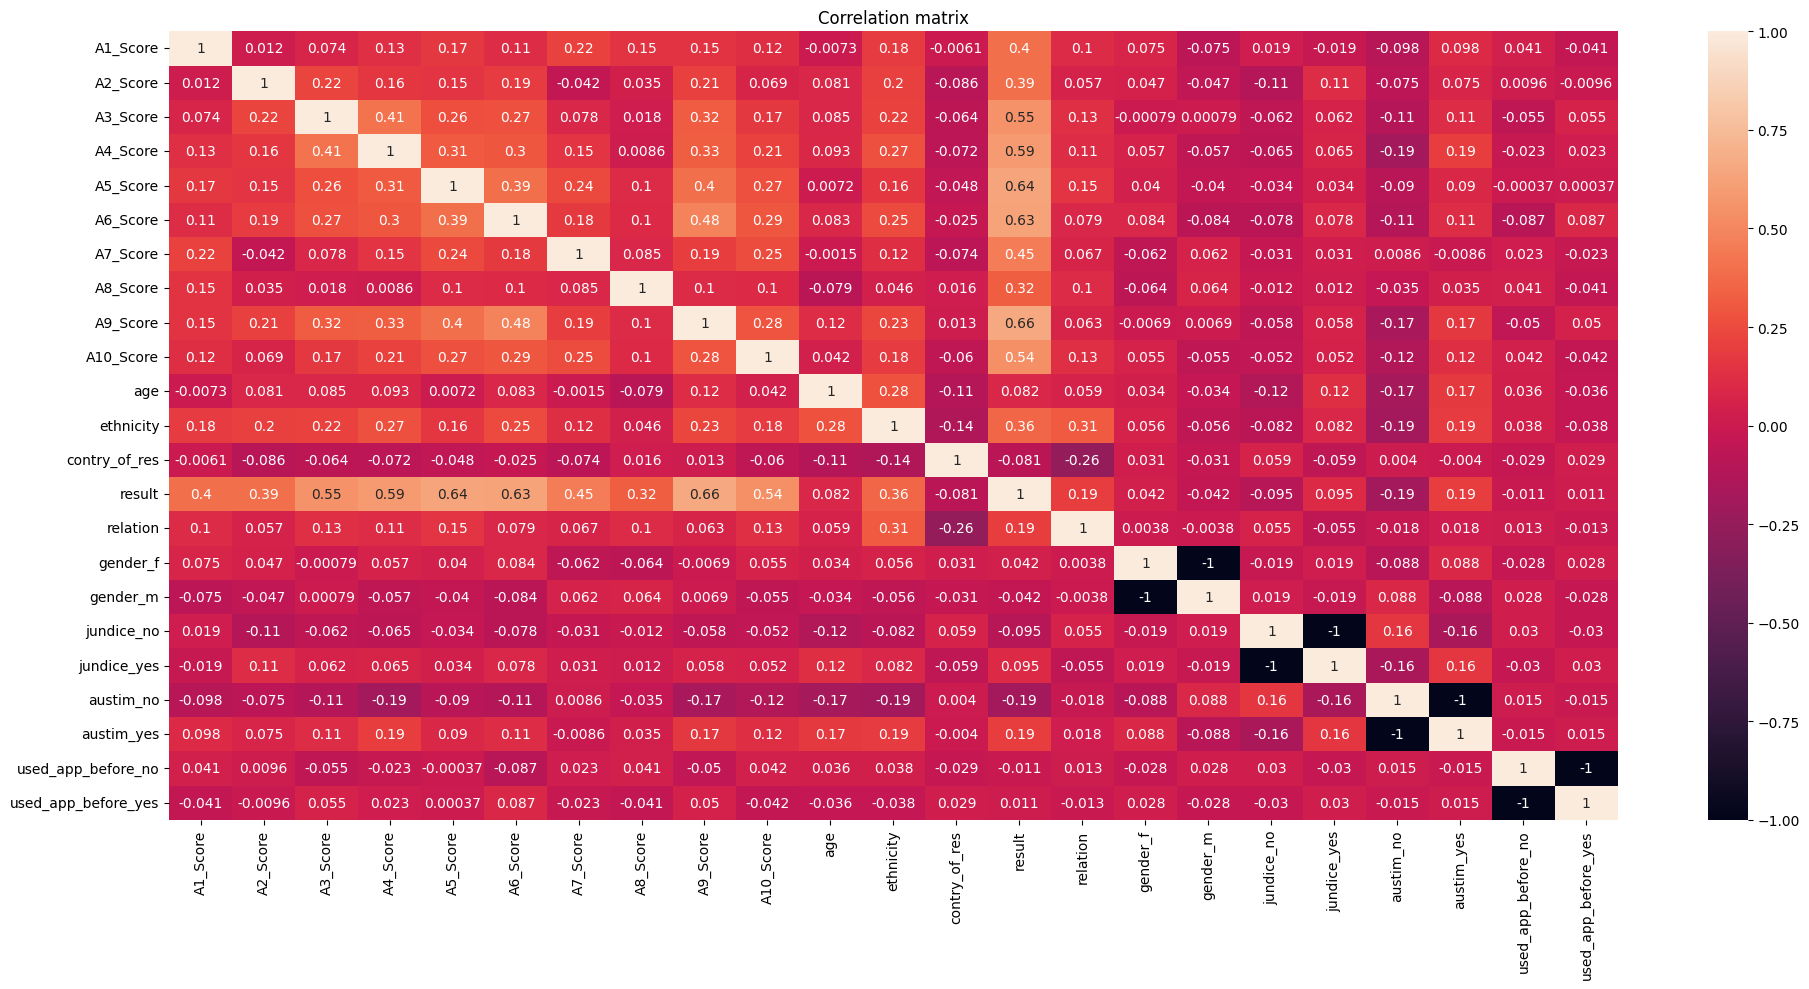

In [21]:
plt.figure(figsize=(20,10))
sns.heatmap(data_X.corr(),annot=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

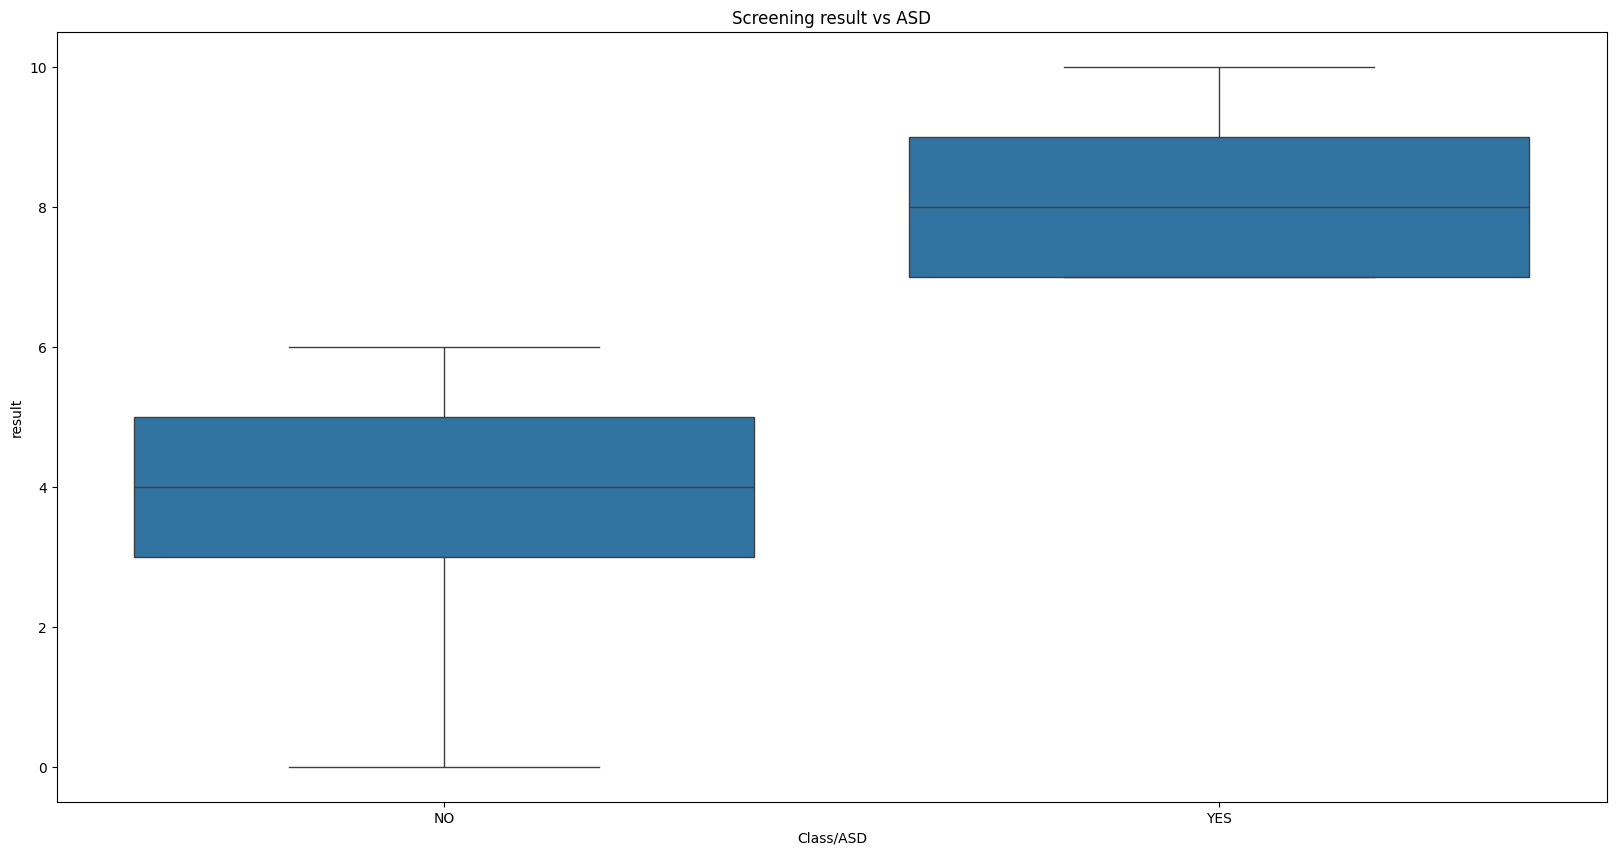

In [22]:
plt.figure(figsize=(20,10))
sns.boxplot(x="Class/ASD",y="result",data=df)
plt.title("Screening result vs ASD")
plt.show()

In [23]:
X=data_X
Y=y_df

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,shuffle=True,stratify=Y,random_state=1)

In [24]:
dt=DecisionTreeClassifier(max_depth=5,random_state=1)
dt.fit(X_train,Y_train)
y_dt=dt.predict(X_test)
y_dtAcc=dt.score(X_test,Y_test)

In [25]:
print(classification_report(Y_test,y_dt))
confusion_matrix(Y_test,y_dt)

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       103
         YES       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



array([[103,   0],
       [  0,  38]])

In [26]:
rf=RandomForestClassifier(n_estimators=100,random_state=1)
rf.fit(X_train,Y_train)
y_rf=rf.predict(X_test)
y_rfAcc=rf.score(X_test,Y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [27]:
print(classification_report(Y_test,y_rf))
confusion_matrix(Y_test,y_rf)

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       103
         YES       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



array([[103,   0],
       [  0,  38]])

In [28]:
svm=SVC()
svm.fit(X_train,Y_train)
y_svm=svm.predict(X_test)
y_svmAcc=svm.score(X_test,Y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
print(classification_report(Y_test,y_svm))
confusion_matrix(Y_test,y_svm)

              precision    recall  f1-score   support

          NO       0.91      1.00      0.95       103
         YES       1.00      0.74      0.85        38

    accuracy                           0.93       141
   macro avg       0.96      0.87      0.90       141
weighted avg       0.94      0.93      0.93       141



array([[103,   0],
       [ 10,  28]])

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
knn=KNeighborsClassifier(5)
knn.fit(X_train,Y_train)
y_knn=knn.predict(X_test)
y_knnAcc=knn.score(X_test,Y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [32]:
print(classification_report(Y_test,y_knn))
confusion_matrix(Y_test,y_knn)

              precision    recall  f1-score   support

          NO       0.88      0.92      0.90       103
         YES       0.76      0.66      0.70        38

    accuracy                           0.85       141
   macro avg       0.82      0.79      0.80       141
weighted avg       0.85      0.85      0.85       141



array([[95,  8],
       [13, 25]])

In [33]:
data={
    "Metrics":["ACC"],
    "Tree":[y_dtAcc],
    "Forest":[y_rfAcc],
    "SVM":[y_svmAcc],
    "KNN":[y_knnAcc],
}

In [34]:
print("Comparison")
comparison=pd.DataFrame(data,columns=["Metrics","Tree","Forest","SVM","KNN"])
comparison

Comparison


,Metrics,Tree,Forest,SVM,KNN
0,ACC,1.0,1.0,0.929078,0.851064
